# **1. Import Necessary Libraries**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import cv2
from PIL import Image
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Image Preprocessing**

In [14]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [15]:
# Folder where the images are
base_folder = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images"

In [ ]:
# Output folder
output_folder = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images_224"

In [ ]:
for split in ["train", "test", "valid"]:  # visits all the folders
  for cls in ["hotspot", "clean"]:
    src_folder = os.path.join(base_folder, split, cls)  # original folder
    dst_folder = os.path.join(output_folder, split, cls)  # destination folder

    # Make the directories if they don't exist
    os.makedirs(dst_folder, exist_ok=True)

    # Loop through each file in the folder
    for img_name in os.listdir(src_folder):

      # Comvine folder name into full path
      img_path = os.path.join(src_folder, img_name)

      try:

        # Open the image and resize
        with Image.open(img_path) as img:
          img_resized = img.resize(IMG_SIZE)

          # Save the resized image into a new folder with the same file name
          img_resized.save(os.path.join(dst_folder, img_name))
      except Exception as e:
        print(f"Error processing {img_path}: {e}")

Error processing /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images/train/hotspot/_classes.csv: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images/train/hotspot/_classes.csv'
Error processing /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images/test/hotspot/_classes.csv: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images/test/hotspot/_classes.csv'
Error processing /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images/valid/hotspot/_classes.csv: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images/valid/hotspot/_classes.csv'


In [16]:
# Copied to runtime for faster training
!cp -r "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/PV_Images_224" /content/

In [17]:
# Data generators to normalize the images
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [18]:
# Load the images
train_gen = train_datagen.flow_from_directory(
    "/content/PV_Images_224/train",
    target_size = IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = train_datagen.flow_from_directory(
    "/content/PV_Images_224/test",
    target_size = IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_gen = train_datagen.flow_from_directory(
    "/content/PV_Images_224/valid",
    target_size = IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 3594 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Found 497 images belonging to 2 classes.


# **3. Model Training**

In [19]:
# Create base dense net without top layer
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False    # freeze pre trained layers

In [20]:
# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summarise the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,568,001 (70.83 MB)

 Trainable params: 246,017 (961.00 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [21]:
# Add callbacks to prevet overfitting
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [22]:
# Train the model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    callbacks=[earlystop]
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1254s 11s/step - accuracy: 0.9557 - loss: 0.0782 - val_accuracy: 1.0000 - val_loss: 6.3407e-05
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1198s 11s/step - accuracy: 1.0000 - loss: 7.2241e-05 - val_accuracy: 1.0000 - val_loss: 3.0564e-05
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1225s 11s/step - accuracy: 1.0000 - loss: 3.4251e-05 - val_accuracy: 1.0000 - val_loss: 1.7171e-05
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1198s 11s/step - accuracy: 1.0000 - loss: 3.0155e-05 - val_accuracy: 1.0000 - val_loss: 1.0900e-05
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 1223s 11s/step - accuracy: 1.0000 - loss: 2.1003e-05 - val_accuracy: 1.0000 - val_loss: 7.6745e-06


# **4. Model Evaluation**

In [24]:
# evaluate the model
test_loss, test_accuracy = model.evaluate(test_gen)
print("Test accuracy:", test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 125s 9s/step - accuracy: 1.0000 - loss: 1.3129e-05
Test accuracy: 1.0


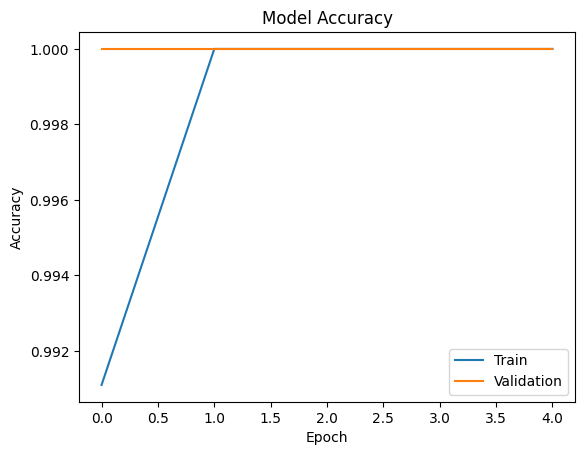

In [25]:
# Plot training progress
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [26]:
# save for further use
model.save("/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/densenet201_base_trained_model.h5")

In [28]:
# Classification report
print(classification_report(test_gen.classes, np.round(model.predict(test_gen))))

14/14 ━━━━━━━━━━━━━━━━━━━━ 186s 12s/step
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       319
           1       0.25      0.25      0.25       101

    accuracy                           0.64       420
   macro avg       0.50      0.50      0.50       420
weighted avg       0.64      0.64      0.64       420



14/14 ━━━━━━━━━━━━━━━━━━━━ 125s 9s/step


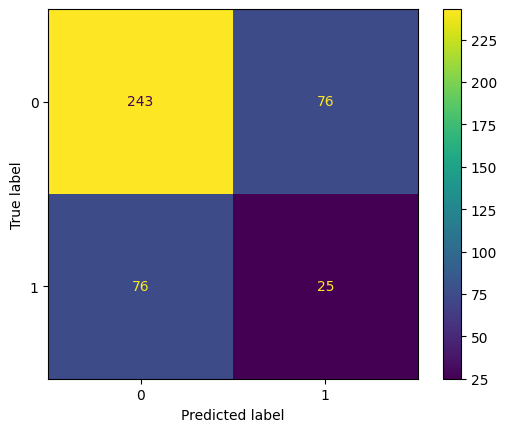

In [29]:
# Confusion matrix
cm = confusion_matrix(test_gen.classes, np.round(model.predict(test_gen)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()